Target Energi Max : 147.5 MeV
Rentang SOBP      : 12.93 cm hingga 15.18 cm


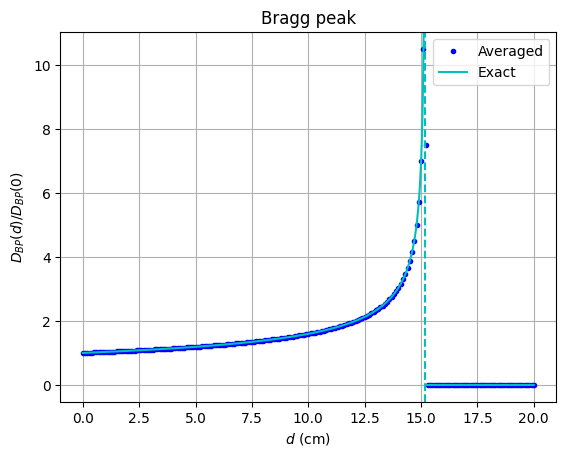

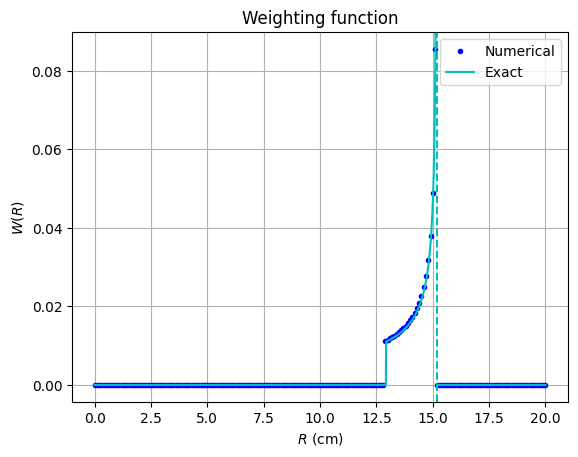

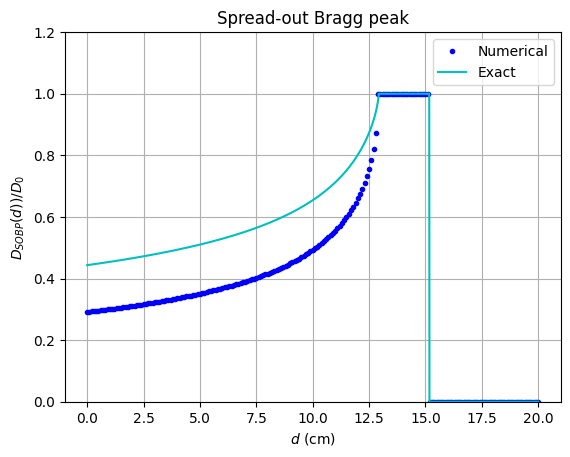


 HASIL EKSTRAKSI 23 BEAM BORTFELD UNTUK SIMULASI TOPAS
Layer Energi ke- 1 : 147.08 MeV (Jangkauan: 15.1 cm) -> 100000 partikel
Layer Energi ke- 2 : 146.53 MeV (Jangkauan: 15.0 cm) ->  56990 partikel
Layer Energi ke- 3 : 145.97 MeV (Jangkauan: 14.9 cm) ->  44371 partikel
Layer Energi ke- 4 : 145.42 MeV (Jangkauan: 14.8 cm) ->  37194 partikel
Layer Energi ke- 5 : 144.86 MeV (Jangkauan: 14.7 cm) ->  32483 partikel
Layer Energi ke- 6 : 144.31 MeV (Jangkauan: 14.6 cm) ->  29101 partikel
Layer Energi ke- 7 : 143.75 MeV (Jangkauan: 14.5 cm) ->  26530 partikel
Layer Energi ke- 8 : 143.19 MeV (Jangkauan: 14.4 cm) ->  24493 partikel
Layer Energi ke- 9 : 142.62 MeV (Jangkauan: 14.3 cm) ->  22832 partikel
Layer Energi ke-10 : 142.06 MeV (Jangkauan: 14.2 cm) ->  21446 partikel
Layer Energi ke-11 : 141.49 MeV (Jangkauan: 14.1 cm) ->  20266 partikel
Layer Energi ke-12 : 140.92 MeV (Jangkauan: 14.0 cm) ->  19248 partikel
Layer Energi ke-13 : 140.35 MeV (Jangkauan: 13.9 cm) ->  18359 partikel
Layer En

In [8]:
import numpy as np
from scipy import signal, integrate
import matplotlib.pyplot as plt

# =========================================================
# 1. PENGATURAN PARAMETER ENERGI DAN TARGET DINAMIS
# =========================================================
# Silakan ubah E_max ke 150.0, 100.0, atau berapapun yang Anda inginkan
E_max = 147.5       # Energi proyektil maksimal (dalam MeV) 
lebar_sobp = 2.25    # Lebar dataran SOBP yang diinginkan (dalam cm)

# Parameter Fisika Medium (PMMA/Air)
alpha = 0.0022      # Konstanta empiris
p = 1.77            # Eksponen empiris
D0 = 1.0            # Dosis target SOBP (Relatif)

# =========================================================
# KONVERSI OTOMATIS: Energi -> Kedalaman (Sumbu Z)
# =========================================================
# Rumus range-energy Bortfeld: R = alpha * E^p
db = alpha * (E_max ** p)     # Kedalaman berhentinya proton terdalam (Distal Edge)
da = db - lebar_sobp          # Kedalaman awal tumor (Proximal Edge)

print(f"Target Energi Max : {E_max} MeV")
print(f"Rentang SOBP      : {da:.2f} cm hingga {db:.2f} cm")

# Shorthand for oft-used expressions
a = alpha**(1.0/p)
q = 1.0 - 1.0/p

# Stopping power S = -dE/dd, mirrored about the y-axis and shifted by db (Bortfeld & Schlegel (1996), Eq. (A5))
def g(d):
    return np.piecewise(d,[d<0,d>0],[0,lambda d: 1.0/(p*a*d**q)])

def Bragg_peak(R,d):
    return g(R-d)

# Numerically computes the average of a function "func" on the interval [d0,d1]
def average(func,d0,d1):
    integral,_ = integrate.quad(func,d0,d1)/(d1-d0)
    return integral

# For a function defined for x>0, given an array x of grid values, returns an array of average
# function values on intervals [x[n]-dx/2, x[n]+dx/2], where x[n] is a grid value and dx the grid spacing
def impulse(func,x):
    h = np.zeros(len(x))
    dx = x[1] - x[0]
    h[0] = average(func, 0, 0.5*dx)
    for n in range(1,N):
        h[n] = average(func, x[n]-0.5*dx, x[n]+0.5*dx)
    return h

def W(R):
    return np.piecewise(R,[(da<=R) & (R<db)],[lambda R: D0*p*np.sin(np.pi/p)*a/(np.pi*(db-R)**(1.0/p)), 0])

# Performs the reverse of the transforms defined in Eq. (A3) of Bortfeld & Schlegel (1996)
def back_transform(w,da,db,x):
    N = len(x)
    dx = x[1] - x[0]
    Na = int(da/dx)
    Nb = int(db/dx)
    w = w[:Nb+1]
    w_reverse = w[::-1]
    return np.concatenate((np.zeros(Na), w_reverse[Na:Nb+1], np.zeros(N-Nb-1)))

# Part of the exact solution of the spread-out Bragg peak for p = 1.5 (Bortfeld & Schlegel (1996), Eq. (6))
def SOBP_buildup(d,da,db,D0):
    r = (da - d)/(db - da)
    r_hat = r**(1.0/3.0)
    return D0*(0.75+np.sqrt(3)/(4*np.pi)*np.log((1+r_hat)**2/(1-r_hat+r_hat**2))-3.0/(2.0*np.pi)*np.arctan((2*r_hat-1)/np.sqrt(3)))

# Full piecewise-defined analytical solution for the SOBP with p = 1.5 (Bortfeld & Schlegel (1996), Eq. (6))
def SOBP_analytic(d,da,db,D0):
    return np.piecewise(d,[(0<=d) & (d<da),(da<=d) & (d<=db)],[lambda d: SOBP_buildup(d,da,db,D0), D0, 0])

# Add grid and legend to plots
def add_grid_legend():
    plt.grid('on')
    handles, labels = plt.gca().get_legend_handles_labels()
    plt.legend(handles, labels, loc = 'best')

# Definition of the depth grid
N = 201                         # Number of grid points
dmax = 20.0                     # Maximum depth up to which to generate model output
d = np.linspace(0,dmax,N)       # Depth grid
dd = d[1] - d[0]                # Depth grid spacing
Na = int(da/dd)                 # Grid point index corresponding to d = da
Nb = int(db/dd)                 # Grid point index corresponding to d = db

g_avs = impulse(g,d)            # Impulse response function (with averaging applied to remove singularity)

M = N                           # Length of inverse filter response w(R)
d_w = np.arange(M)*dd           # Depth grid for w(R)
Nd = M + N - 1                  # Number of output samples needed to obtain the inverse filter response of the required length

yd = D0*np.ones(Nd)             # Heaviside step function of length Nd

# Perform deconvolution of the step function with the averaged impulse response
w, remainder = signal.deconvolve(yd,g_avs)
w /= dd                        # Divide by grid spacing to obtain an approxiamtion of the continuous-valued weighting function

w2 = back_transform(w,da,db,d)

# Obtain the spread-out Bragg peak by deconvolution (cf. Bortfeld & Schlegel (1996), Eq. (B1))
SOBP = dd * signal.convolve(w2,g_avs[::-1])
SOBP = SOBP[N-1:]               # Remove boundary effects at the beginning of the convolution output

# Figure 1: Illustration of the Bragg peak
plt.figure(1)
Ncont = 2001                        # More finely spaced, 'continuous' grid for plotting exact solution
dcont = np.linspace(0,dmax,Ncont)
dx_cont = dcont[1] - dcont[0]

gx = Bragg_peak(db,dcont)           # Exact Bragg peak (Bortfeld & Schlegel, Eq. (3))
gx /= gx[0]                         # Normalize by value at d = 0
gx[int(db/dx_cont)] = np.nan                 # Set to not-a-number at the singularity at d = db

gn = impulse(lambda d: Bragg_peak(db,d),d)      # Discretized Bragg peak in which the singularity at d = db is removed by averaging
gn /= gn[0]                                     # Normalized by value at d = 0

plt.plot(d,gn,'b.',label='Averaged')
ymin,ymax = plt.gca().get_ylim()                # Record auto-scaled axis limits for the discrete (averaged) Bragg peak only
plt.plot(dcont,gx,'c',label='Exact')
plt.axvline(x=db,color='c',linestyle='--')
plt.title("Bragg peak")
plt.xlabel('$d$ (cm)')
plt.ylabel(r'$D_{BP}\left( d \right)/D_{BP}\left( 0 \right)$')
plt.gca().set_ylim(ymin,ymax)
add_grid_legend()

# Figure 2: Weighting function
plt.figure(2)
wx = W(dcont)           # Exact weighting function (Bortfeld & Schlegel (1996), Eq. (4))
wx[int(db/dx_cont)] = np.nan
plt.plot(d,w2,'b.',label='Numerical')
ymin,ymax = plt.gca().get_ylim()                # Record auto-scaled axis limits
plt.plot(dcont,wx,'c',label='Exact')
plt.axvline(x=db,color='c',linestyle='--')
plt.xlabel('$R$ (cm)')
plt.ylabel(r'$W\left(R\right)$')
plt.title('Weighting function')
plt.gca().set_ylim(ymin,ymax)
add_grid_legend()

# Figure 3: Spread-out Bragg peak
plt.figure(3)
plt.plot(d,SOBP,'b.',label='Numerical')
plt.plot(dcont,SOBP_analytic(dcont,da,db,D0),'c',label='Exact')
plt.xlabel('$d$ (cm)')
plt.ylabel('$D_{SOBP}(d))/D_0$')
plt.title('Spread-out Bragg peak')
plt.ylim([0,1.2*D0])
add_grid_legend()

plt.show()

# ---------------------------------------------------------
# TAMBAHAN KODE UNTUK EKSTRAKSI DATA KE TOPAS
# ---------------------------------------------------------
# 1. Ekstrak Range (cm) dan Bobot mentah dari area target SOBP
# Indeks Na hingga Nb mewakili kedalaman dari 13.0 cm s/d 15.0 cm
beam_ranges = d[Na:Nb+1]
beam_weights_raw = w2[Na:Nb+1]

# 2. Konversi Range (cm) menjadi Energi (MeV)
# Menggunakan balikan rumus empiris Bortfeld: R = alpha * E^p -> E = (R / alpha)**(1/p)
beam_energies = (beam_ranges / alpha) ** (1.0 / p)

# 3. Normalisasi bobot menjadi skala jumlah partikel TOPAS (Maksimal 100.000 partikel)
max_weight = np.max(beam_weights_raw)
particle_weights = np.round((beam_weights_raw / max_weight) * 100000).astype(int)

# 4. Tampilkan hasil dari Energi TERTINGGI (Paling dalam) ke TERENDAH
print(f"\n{'='*68}")
print(f" HASIL EKSTRAKSI {len(beam_ranges)} BEAM BORTFELD UNTUK SIMULASI TOPAS")
print(f"{'='*68}")

# Looping mundur agar urutan output dimulai dari energi penetrasi terdalam (15 cm) 
# yang dibutuhkan untuk file PRISTINE.txt
for i in range(len(beam_ranges) - 1, -1, -1):
    energi_mev = beam_energies[i]
    jangkauan_cm = beam_ranges[i]
    bobot = particle_weights[i]
    urutan = len(beam_ranges) - i
    
    print(f"Layer Energi ke-{urutan:2d} : {energi_mev:6.2f} MeV (Jangkauan: {jangkauan_cm:4.1f} cm) -> {bobot:6d} partikel")
print(f"{'='*68}\n")